In [1]:
import pandas as pd
import numpy as np
import warnings
# Note: Obesity, Sleep, Nutrition are constant in this dataset by design
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)

#%% Cell 2 — Load data
file_path = 'data_sample.xlsx'  

df_raw = pd.read_excel(file_path)

print(f"  Rows: {df_raw.shape[0]}")
print(f"  Cols: {df_raw.shape[1]}")

  Rows: 50
  Cols: 18


In [2]:
print("=" * 60)
print("Original Column Names")
print("=" * 60)
for i, col in enumerate(df_raw.columns):
    print(f"  [{i:2d}] {col}")

Original Column Names
  [ 0] dif_nutrition
  [ 1] c_val_nutrition
  [ 2] dif_obesity
  [ 3] c_val_obesity
  [ 4] dif_sleep
  [ 5] c_val_sleep
  [ 6] dif_depression
  [ 7] c_val_depression
  [ 8] dif_wellness
  [ 9] c_val_wellness
  [10] dif_anti_stress
  [11] c_val_anti_stress
  [12] dif_anti_smoke
  [13] c_val_anti_smoke
  [14] dif_movement
  [15] c_val_movement
  [16] recommendations
  [17] status_assessment


In [3]:
cols_to_drop = [c for c in df_raw.columns if 'Unnamed' in str(c)]
print(f"Dropping columns: {cols_to_drop}")

df = df_raw.drop(columns=cols_to_drop)

print(f"\nCleaned columns ({df.shape[1]}):")
for i, col in enumerate(df.columns):
    print(f"  [{i:2d}] {col}")

Dropping columns: []

Cleaned columns (18):
  [ 0] dif_nutrition
  [ 1] c_val_nutrition
  [ 2] dif_obesity
  [ 3] c_val_obesity
  [ 4] dif_sleep
  [ 5] c_val_sleep
  [ 6] dif_depression
  [ 7] c_val_depression
  [ 8] dif_wellness
  [ 9] c_val_wellness
  [10] dif_anti_stress
  [11] c_val_anti_stress
  [12] dif_anti_smoke
  [13] c_val_anti_smoke
  [14] dif_movement
  [15] c_val_movement
  [16] recommendations
  [17] status_assessment


In [4]:
range_cols = [c for c in df.columns if c.startswith('dif_') or c.startswith('c_val_')]
text_cols = [c for c in df.columns if c in ['recommendations', 'status_assessment']]
other_cols = [c for c in df.columns if c not in range_cols + text_cols]

print("=" * 60)
print("Column Classification")
print("=" * 60)
print(f"Range columns ({len(range_cols)}): {range_cols}")
print(f"Text  columns ({len(text_cols)}):  {text_cols}")
if other_cols:
    print(f"Other columns ({len(other_cols)}):  {other_cols}")

print(f"\nDtype distribution:")
print(df.dtypes.value_counts())

Column Classification
Range columns (16): ['dif_nutrition', 'c_val_nutrition', 'dif_obesity', 'c_val_obesity', 'dif_sleep', 'c_val_sleep', 'dif_depression', 'c_val_depression', 'dif_wellness', 'c_val_wellness', 'dif_anti_stress', 'c_val_anti_stress', 'dif_anti_smoke', 'c_val_anti_smoke', 'dif_movement', 'c_val_movement']
Text  columns (2):  ['recommendations', 'status_assessment']

Dtype distribution:
object    18
Name: count, dtype: int64


In [5]:
print("=" * 60)
print("df.info()")
print("=" * 60)
df.info()

df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   dif_nutrition      50 non-null     object
 1   c_val_nutrition    50 non-null     object
 2   dif_obesity        50 non-null     object
 3   c_val_obesity      50 non-null     object
 4   dif_sleep          50 non-null     object
 5   c_val_sleep        50 non-null     object
 6   dif_depression     50 non-null     object
 7   c_val_depression   50 non-null     object
 8   dif_wellness       50 non-null     object
 9   c_val_wellness     50 non-null     object
 10  dif_anti_stress    50 non-null     object
 11  c_val_anti_stress  50 non-null     object
 12  dif_anti_smoke     50 non-null     object
 13  c_val_anti_smoke   50 non-null     object
 14  dif_movement       50 non-null     object
 15  c_val_movement     50 non-null     object
 16  recommendations    50 non-null     o

In [6]:
print("=" * 60)
print("Duplicate Row Check")
print("=" * 60)

full_dup = df.duplicated().sum()
print(f"Fully duplicated rows:       {full_dup} ({full_dup/len(df)*100:.1f}%)")

range_dup = df.duplicated(subset=range_cols).sum()
print(f"Range-only duplicated rows:  {range_dup} ({range_dup/len(df)*100:.1f}%)")


Duplicate Row Check
Fully duplicated rows:       0 (0.0%)
Range-only duplicated rows:  0 (0.0%)


In [7]:
df.describe(include='all')

,dif_nutrition,c_val_nutrition,dif_obesity,c_val_obesity,dif_sleep,c_val_sleep,dif_depression,c_val_depression,dif_wellness,c_val_wellness,dif_anti_stress,c_val_anti_stress,dif_anti_smoke,c_val_anti_smoke,dif_movement,c_val_movement,recommendations,status_assessment
count,50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,50
unique,1,1,1,1,1,3,3,4,3,4,3,4,3,4,3,4,50,50
top,(-250)-0,600-1000,(-1000)-(-250),0-400,(-250)-0,400-600,(-250)-0,600-1000,(-250)-0,1000-1500,0-250,1000-1500,0-250,400-600,250-1000,400-600,Pick up a nice plushy to help you sleep. Don't spend too much time in one pl...,"Be careful! You need to start improving with respect to your Obesity, Sleep,..."
freq,50,50,50,50,50,19,21,14,19,15,19,18,21,17,21,17,1,1


In [8]:
print("=" * 60)
print("Range Distribution per Column")
print("=" * 60)

for col in range_cols:
    vc = df[col].value_counts()
    print(f"\n  {col} — {len(vc)} unique range(s), {len(df)} total rows:")
    for val, cnt in vc.items():
        print(f"    {str(val):25s}  n={cnt:>6d}  ({cnt/len(df)*100:.1f}%)")

Range Distribution per Column

  dif_nutrition — 1 unique range(s), 50 total rows:
    (-250)-0                   n=    50  (100.0%)

  c_val_nutrition — 1 unique range(s), 50 total rows:
    600-1000                   n=    50  (100.0%)

  dif_obesity — 1 unique range(s), 50 total rows:
    (-1000)-(-250)             n=    50  (100.0%)

  c_val_obesity — 1 unique range(s), 50 total rows:
    0-400                      n=    50  (100.0%)

  dif_sleep — 1 unique range(s), 50 total rows:
    (-250)-0                   n=    50  (100.0%)

  c_val_sleep — 3 unique range(s), 50 total rows:
    400-600                    n=    19  (38.0%)
    600-1000                   n=    19  (38.0%)
    0-400                      n=    12  (24.0%)

  dif_depression — 3 unique range(s), 50 total rows:
    (-250)-0                   n=    21  (42.0%)
    250-1000                   n=    17  (34.0%)
    0-250                      n=    12  (24.0%)

  c_val_depression — 4 unique range(s), 50 total rows:
    

In [9]:
import re

def range_to_mid(s):
    m = re.match(r'\(?(-?\d+)\)?\s*-\s*\(?(-?\d+)\)?', str(s).strip())
    if m:
        return (float(m.group(1)) + float(m.group(2))) / 2
    return None

for col in range_cols:
    df[col + '_mid'] = df[col].apply(range_to_mid)

mid_cols = [c + '_mid' for c in range_cols]
print(f"Created {len(mid_cols)} mid columns:")
for c in mid_cols:
    print(f"  {c}: {df[c].nunique()} unique values, range [{df[c].min()}, {df[c].max()}]")

#%% Cell 19 — Preview
df[mid_cols].head(10)


Created 16 mid columns:
  dif_nutrition_mid: 1 unique values, range [-125.0, -125.0]
  c_val_nutrition_mid: 1 unique values, range [800.0, 800.0]
  dif_obesity_mid: 1 unique values, range [-625.0, -625.0]
  c_val_obesity_mid: 1 unique values, range [200.0, 200.0]
  dif_sleep_mid: 1 unique values, range [-125.0, -125.0]
  c_val_sleep_mid: 3 unique values, range [200.0, 800.0]
  dif_depression_mid: 3 unique values, range [-125.0, 625.0]
  c_val_depression_mid: 4 unique values, range [200.0, 1250.0]
  dif_wellness_mid: 3 unique values, range [-125.0, 625.0]
  c_val_wellness_mid: 4 unique values, range [200.0, 1250.0]
  dif_anti_stress_mid: 3 unique values, range [-125.0, 625.0]
  c_val_anti_stress_mid: 4 unique values, range [200.0, 1250.0]
  dif_anti_smoke_mid: 3 unique values, range [-125.0, 625.0]
  c_val_anti_smoke_mid: 4 unique values, range [200.0, 1250.0]
  dif_movement_mid: 3 unique values, range [-125.0, 625.0]
  c_val_movement_mid: 4 unique values, range [200.0, 1250.0]


,dif_nutrition_mid,c_val_nutrition_mid,dif_obesity_mid,c_val_obesity_mid,dif_sleep_mid,c_val_sleep_mid,dif_depression_mid,c_val_depression_mid,dif_wellness_mid,c_val_wellness_mid,dif_anti_stress_mid,c_val_anti_stress_mid,dif_anti_smoke_mid,c_val_anti_smoke_mid,dif_movement_mid,c_val_movement_mid
0,-125.0,800.0,-625.0,200.0,-125.0,200.0,625.0,200.0,625.0,200.0,625.0,1250.0,-125.0,200.0,-125.0,500.0
1,-125.0,800.0,-625.0,200.0,-125.0,500.0,625.0,800.0,-125.0,500.0,625.0,1250.0,125.0,800.0,-125.0,500.0
2,-125.0,800.0,-625.0,200.0,-125.0,500.0,125.0,800.0,-125.0,1250.0,625.0,200.0,125.0,200.0,625.0,800.0
3,-125.0,800.0,-625.0,200.0,-125.0,500.0,-125.0,500.0,-125.0,1250.0,125.0,1250.0,625.0,800.0,-125.0,800.0
4,-125.0,800.0,-625.0,200.0,-125.0,800.0,625.0,500.0,-125.0,1250.0,125.0,800.0,625.0,500.0,625.0,800.0
5,-125.0,800.0,-625.0,200.0,-125.0,500.0,-125.0,500.0,625.0,800.0,-125.0,1250.0,125.0,1250.0,-125.0,800.0
6,-125.0,800.0,-625.0,200.0,-125.0,500.0,-125.0,500.0,625.0,1250.0,-125.0,200.0,-125.0,500.0,625.0,500.0
7,-125.0,800.0,-625.0,200.0,-125.0,800.0,125.0,200.0,625.0,200.0,625.0,800.0,625.0,800.0,-125.0,800.0
8,-125.0,800.0,-625.0,200.0,-125.0,800.0,-125.0,200.0,625.0,800.0,625.0,500.0,-125.0,800.0,-125.0,200.0
9,-125.0,800.0,-625.0,200.0,-125.0,500.0,-125.0,200.0,-125.0,200.0,-125.0,1250.0,-125.0,500.0,-125.0,1250.0


In [10]:
print("=" * 60)
print("Text Column Overview")
print("=" * 60)

for col in text_cols:
    s = df[col].astype(str)
    print(f"\n  {col}:")
    print(f"    Unique values: {s.nunique()}")
    print(f"    Avg length:    {s.str.len().mean():.0f} chars")
    print(f"    Min length:    {s.str.len().min()} chars")
    print(f"    Max length:    {s.str.len().max()} chars")

Text Column Overview

  recommendations:
    Unique values: 50
    Avg length:    271 chars
    Min length:    160 chars
    Max length:    407 chars

  status_assessment:
    Unique values: 50
    Avg length:    262 chars
    Min length:    167 chars
    Max length:    291 chars


In [11]:
status_vc = df['status_assessment'].value_counts()
print(f"Total unique: {len(status_vc)}\n")
for i, (text, cnt) in enumerate(status_vc.head(10).items()):
    print(f"  [{i}] (n={cnt}) {text[:150]}...")
    print()


Total unique: 50

  [0] (n=1) Be careful! You need to start improving with respect to your Obesity, Sleep, Nutrition, Anti-Smoke, Movement. You're not immediately at the risk of ge...

  [1] (n=1) Be careful! You need to start improving with respect to your Obesity, Sleep, Nutrition, Depression, Wellness. Your progress has been declining, but yo...

  [2] (n=1) Be careful! You need to start improving with respect to your Obesity, Sleep, Nutrition, Anti-Smoke. Your progress has been declining, but you are stil...

  [3] (n=1) Be careful! You need to start improving with respect to your Obesity, Sleep, Nutrition, Depression, Anti-Stress, Movement. Your progress has been decl...

  [4] (n=1) Be careful! You need to start improving with respect to your Obesity, Sleep, Nutrition, Depression, Movement. Your progress has been declining, but yo...

  [5] (n=1) Be careful! You need to start improving with respect to your Obesity, Sleep, Nutrition, Wellness, Anti-Stress, Anti-Smoke. You're not i

In [12]:
rec_vc = df['recommendations'].value_counts()
print(f"Total unique: {len(rec_vc)}\n")
for i, (text, cnt) in enumerate(rec_vc.head(10).items()):
    print(f"  [{i}] (n={cnt}) {text[:150]}...")
    print()

Total unique: 50

  [0] (n=1) Pick up a nice plushy to help you sleep. Don't spend too much time in one place, take breaks often to walk around or stretch. Consider speaking to a p...

  [1] (n=1) Restrict the intake of sugars-sweetened soft drinks. Pick up a nice plushy to help you sleep. Avoid processed foods and opt for whole grains and veget...

  [2] (n=1) Practice mindfulness or meditation for at least 10 minutes a day. Refrain from using electronics or looking at bright lights at least an hour before y...

  [3] (n=1) Get at least seven hours of sleep per night. Refrain from using electronics or looking at bright lights at least an hour before you sleep. Stay hydrat...

  [4] (n=1) Engage in social activities to improve your mental wellness. Pick up a nice plushy to help you sleep. Increasing levels of physical activity: engaging...

  [5] (n=1) Reduce alcohol consumption to improve overall health. Avoid processed foods and opt for whole grains and vegetables. Don't spend too mu

In [13]:
def extract_dimensions(text):
    text = str(text)
    improving, acceptable = [], []
    
    m1 = re.search(r'improving with respect to your\s+(.+?)\.', text)
    if m1:
        raw = m1.group(1).replace(' and ', ', ')
        improving = [d.strip() for d in raw.split(',') if d.strip()]
    
    m2 = re.search(r'acceptable level for\s+(.+?)\.', text)
    if m2:
        raw = m2.group(1).replace(' and ', ', ')
        acceptable = [d.strip() for d in raw.split(',') if d.strip()]
    
    return improving, acceptable

parsed = df['status_assessment'].apply(extract_dimensions)
df['dims_improving'] = parsed.apply(lambda x: x[0])
df['dims_acceptable'] = parsed.apply(lambda x: x[1])

In [14]:
for i in [0, 2, 5, 10, 30]:
    print(f"\n  Row {i}:")
    print(f"    Improving:  {df['dims_improving'].iloc[i]}")
    print(f"    Acceptable: {df['dims_acceptable'].iloc[i]}")


  Row 0:
    Improving:  ['Obesity', 'Sleep', 'Nutrition', 'Anti-Smoke', 'Movement']
    Acceptable: []

  Row 2:
    Improving:  ['Obesity', 'Sleep', 'Nutrition', 'Wellness']
    Acceptable: ['Depression', 'Anti-Smoke']

  Row 5:
    Improving:  ['Obesity', 'Sleep', 'Nutrition', 'Depression', 'Anti-Stress', 'Movement']
    Acceptable: ['Anti-Smoke']

  Row 10:
    Improving:  ['Obesity', 'Sleep', 'Nutrition', 'Anti-Smoke', 'Movement']
    Acceptable: ['Depression', 'Anti-Stress']

  Row 30:
    Improving:  ['Obesity', 'Sleep', 'Nutrition', 'Wellness', 'Anti-Stress', 'Anti-Smoke']
    Acceptable: []


In [15]:
from collections import Counter

all_dims = Counter()
for dims in df['dims_improving']:
    all_dims.update(dims)
for dims in df['dims_acceptable']:
    all_dims.update(dims)

print("=" * 60)
print(f"All dimension names found ({len(all_dims)} unique)")
print("=" * 60)
for dim, cnt in all_dims.most_common():
    print(f"  {dim}")

All dimension names found (8 unique)
  Obesity
  Sleep
  Nutrition
  Anti-Smoke
  Anti-Stress
  Wellness
  Depression
  Movement


In [16]:
import pandas as pd

dims = [
    "Obesity", "Sleep", "Nutrition", "Movement",
    "Anti-Smoke", "Anti-Stress", "Wellness", "Depression"
]

s = df["status_assessment"].fillna("")

#  improving 
imp_text = (
    s.str.extract(r"improving with respect to your\s+(.+?)\.", expand=False)
     .fillna("")
     .str.replace(r"\s*,\s*", ", ", regex=True)
     .str.replace(r"\s+and\s+", ", ", regex=True)
)

imp_dummy = (
    imp_text
    .str.get_dummies(sep=", ")
    .reindex(columns=dims, fill_value=0)
)

#  acceptable 
acc_text = (
    s.str.extract(r"acceptable level for\s+(.+?)\.", expand=False)
     .fillna("")
     .str.replace(r"\s*,\s*", ", ", regex=True)
     .str.replace(r"\s+and\s+", ", ", regex=True)
)

acc_dummy = (
    acc_text
    .str.get_dummies(sep=", ")
    .reindex(columns=dims, fill_value=0)
)

for d in dims:
    df[f"{d}_status"] = (
        imp_dummy[d] * 1 +
        acc_dummy[d] * 2
    )

# 0 = not mentioned
# 1 = improving
# 2 = acceptable

In [17]:
for d in dims:
    print(d)
    print(df[f"{d}_status"].value_counts())
    print("------")

Obesity
Obesity_status
1    50
Name: count, dtype: int64
------
Sleep
Sleep_status
1    50
Name: count, dtype: int64
------
Nutrition
Nutrition_status
1    50
Name: count, dtype: int64
------
Movement
Movement_status
0    21
1    18
2    11
Name: count, dtype: int64
------
Anti-Smoke
Anti-Smoke_status
2    21
1    17
0    12
Name: count, dtype: int64
------
Anti-Stress
Anti-Stress_status
2    19
1    18
0    13
Name: count, dtype: int64
------
Wellness
Wellness_status
1    19
0    17
2    14
Name: count, dtype: int64
------
Depression
Depression_status
1    21
0    17
2    12
Name: count, dtype: int64
------


In [18]:
unique_sentences = (
    df["recommendations"]
    .str.replace("  ", " ")
    .str.split(". ")
    .explode()
    .str.strip()
    .dropna()
    .unique()
)

print(len(unique_sentences))

122


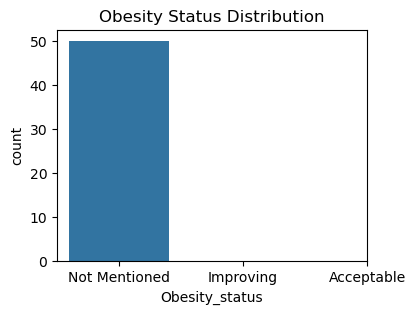

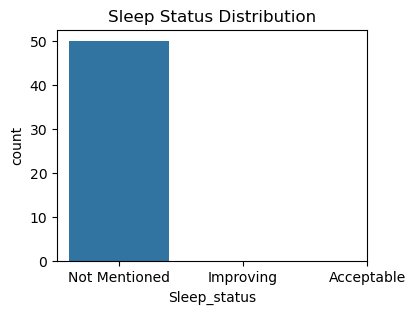

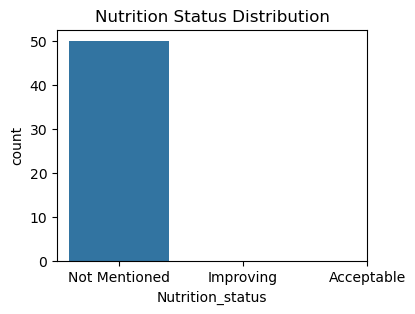

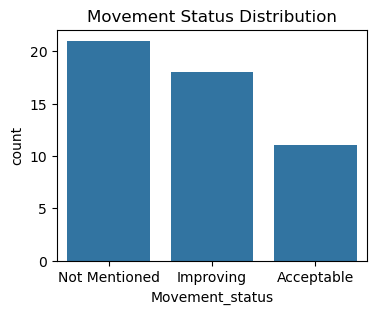

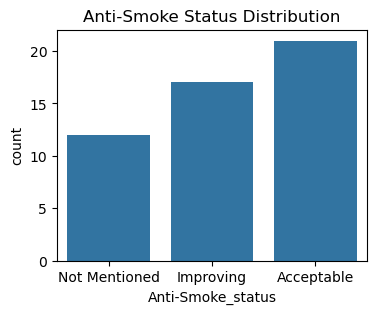

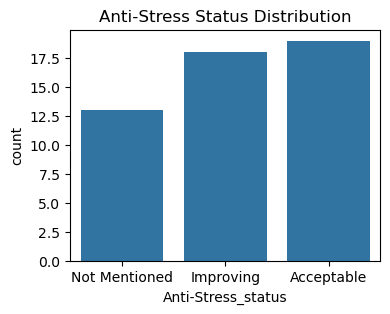

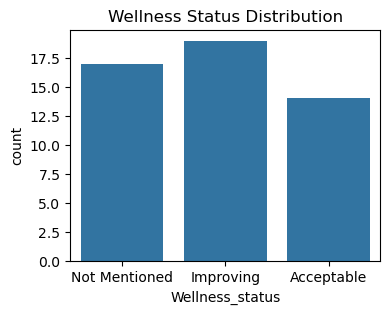

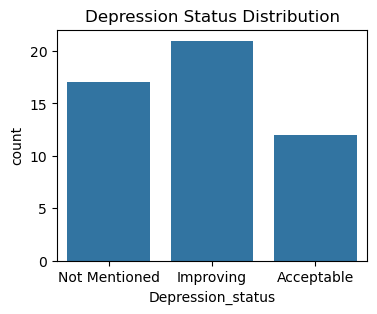

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

dims = [
    "Obesity","Sleep","Nutrition","Movement",
    "Anti-Smoke","Anti-Stress","Wellness","Depression"
]

for d in dims:
    plt.figure(figsize=(4,3))
    sns.countplot(x=f"{d}_status", data=df)
    plt.title(f"{d} Status Distribution")
    plt.xticks([0,1,2], ["Not Mentioned","Improving","Acceptable"])
    plt.show()

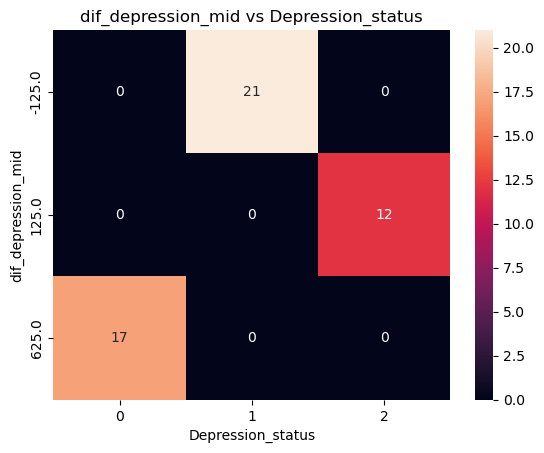

In [20]:
ct = pd.crosstab(df["dif_depression_mid"], df["Depression_status"])

sns.heatmap(ct, annot=True, fmt="d")
plt.title("dif_depression_mid vs Depression_status")
plt.show()

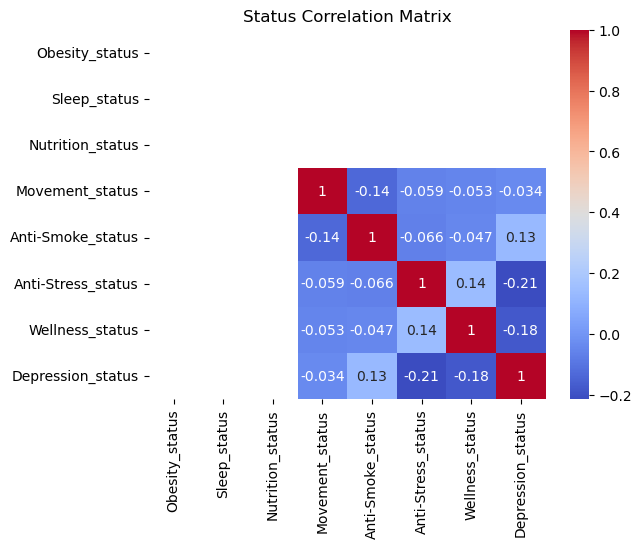

In [21]:
status_cols = [f"{d}_status" for d in dims]

corr = df[status_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Status Correlation Matrix")
plt.show()

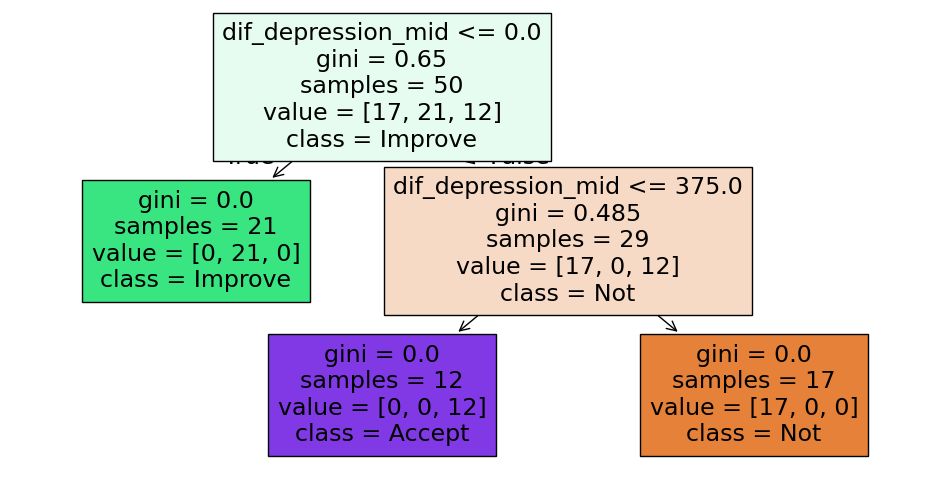

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

X = df[[col for col in df.columns if col.endswith("_mid")]]
y = df["Depression_status"]

tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X, y)

plt.figure(figsize=(12,6))
plot_tree(tree, feature_names=X.columns, class_names=["Not","Improve","Accept"], filled=True)
plt.show()

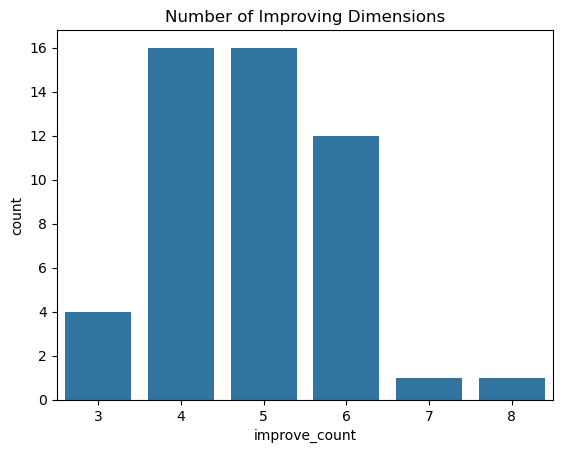

In [23]:
df["improve_count"] = sum(df[f"{d}_status"]==1 for d in dims)

sns.countplot(x="improve_count", data=df)
plt.title("Number of Improving Dimensions")
plt.show()

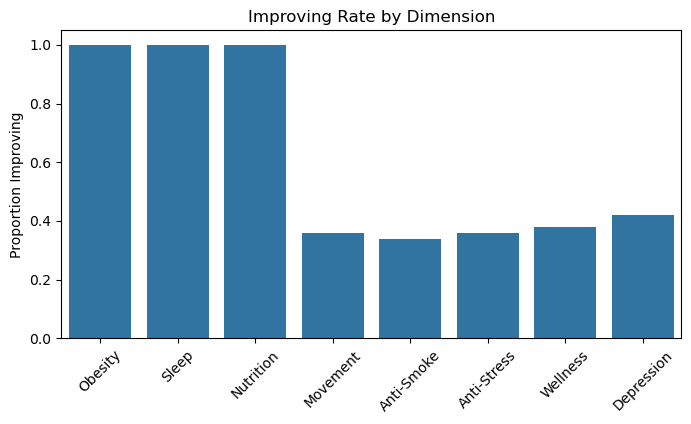

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

dims = ["Obesity","Sleep","Nutrition","Movement",
        "Anti-Smoke","Anti-Stress","Wellness","Depression"]

improve_rates = []

for d in dims:
    rate = (df[f"{d}_status"] == 1).mean()
    improve_rates.append(rate)

plt.figure(figsize=(8,4))
sns.barplot(x=dims, y=improve_rates)
plt.xticks(rotation=45)
plt.title("Improving Rate by Dimension")
plt.ylabel("Proportion Improving")
plt.show()

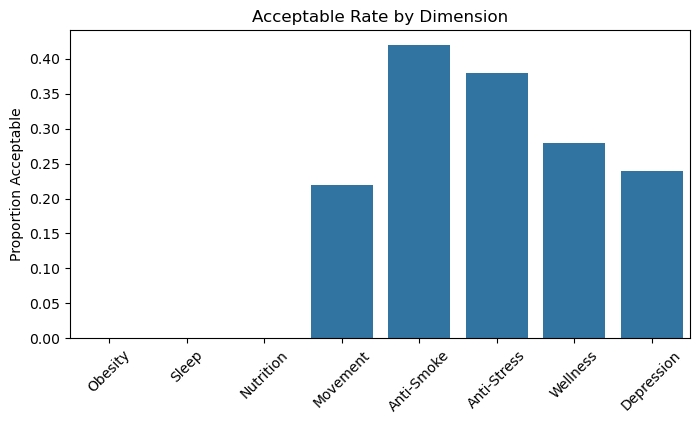

In [25]:
acceptable_rates = []

for d in dims:
    rate = (df[f"{d}_status"] == 2).mean()
    acceptable_rates.append(rate)

plt.figure(figsize=(8,4))
sns.barplot(x=dims, y=acceptable_rates)
plt.xticks(rotation=45)
plt.title("Acceptable Rate by Dimension")
plt.ylabel("Proportion Acceptable")
plt.show()

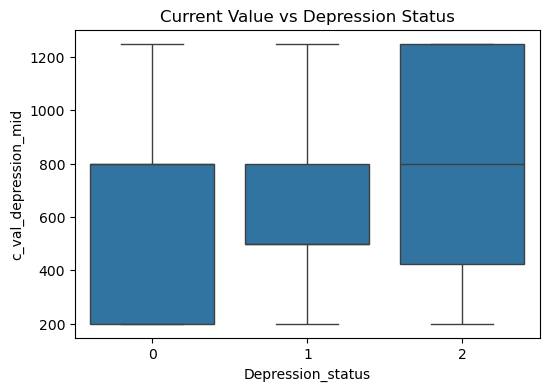

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Depression_status", y="c_val_depression_mid", data=df)
plt.title("Current Value vs Depression Status")
plt.show()

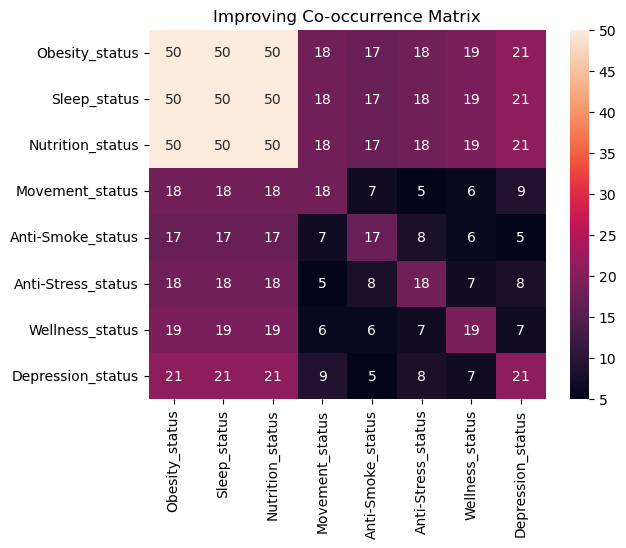

In [27]:
improve_cols = [f"{d}_status" for d in dims]

binary_improve = df[improve_cols].apply(lambda x: (x==1).astype(int))

co_matrix = binary_improve.T @ binary_improve

sns.heatmap(co_matrix, annot=True, fmt="d")
plt.title("Improving Co-occurrence Matrix")
plt.show()

In [28]:
df.to_csv("health_data_1.0.csv", index=False)